# 1. Characterizing the customer
Our objective is to characterize groups of customers based on their
buys. We will check which data from Olist data set can be used for this
reason.

In [1]:
!pip install yellowbrick
!pip install sqlite-utils

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
## python built-in modules
from   pathlib import Path
import sqlite3
import csv

## third party modules
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns

from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.preprocessing   import OrdinalEncoder
from sklearn.preprocessing   import RobustScaler
from sklearn.preprocessing   import MinMaxScaler
from sklearn.cluster         import KMeans
from sklearn.cluster         import AgglomerativeClustering
from sklearn.metrics         import silhouette_score
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from yellowbrick.cluster     import SilhouetteVisualizer
from scipy.cluster.hierarchy import dendrogram

## loads specific package modules, which contain project settings
from client_segmentation.config import PROCESSED_DATA_DIR
from client_segmentation.config import RAW_DATA_DIR
from client_segmentation.config import INTERIM_DATA_DIR

## 1.1 Retrieving data to characterize customer

Regarding data schema show in
[Olist dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce),
we have customer orders and payment data available. So, in order to do
customer segmentation based on their buys, we will use the following
data sets:

- customers
- orders
- order items
- products
- payments

From customers data set, we will obtain customer location and use this
data set with order, order items and products to retrieve their
buys. The payments data set will be useful to obtain payment method and
transaction blue.

First we build a sqlite database with the data we want to use in client
segmentation. Then, we write a SQL query to extract the needed data and
export them into a csv file.

In [11]:
!sqlite-utils insert ../data/processed/ecommerce.db customers ../data/interim/olist_customers_dataset.csv --csv --detect-types

  [####################################]  100%          


In [12]:
!sqlite-utils insert ../data/processed/ecommerce.db orders ../data/interim/olist_orders_dataset.csv --csv --detect-types

  [####################################]  100%          


In [13]:
!sqlite-utils insert ../data/processed/ecommerce.db order_items ../data/interim/olist_order_items_dataset.csv --csv --detect-types

  [####################################]  100%          


In [14]:
!sqlite-utils insert ../data/processed/ecommerce.db products ../data/interim/olist_products_dataset.csv --csv --detect-types

  [####################################]  100%          


In [15]:
!sqlite-utils insert ../data/processed/ecommerce.db order_payments ../data/interim/olist_order_payments_dataset.csv --csv --detect-types

  [####################################]  100%          


In [3]:
con = sqlite3.connect('../data/processed/ecommerce.db')

In [4]:
cur = con.cursor()

Below we create a SQL query to extract data about customer buys and
payment method.

In [24]:
query = """
select c.customer_city,
       c.customer_state,
       oi.price,
       oi.freight_value,
       p.product_category_name,
       op.payment_sequential,
       op.payment_type,
       op.payment_installments,
       op.payment_value
  from customers c
  inner join orders o on o.customer_id = c.customer_id
  inner join order_items oi on oi.order_id = o.order_id
  inner join products p on p.product_id = oi.product_id
  inner join order_payments op on op.order_id = o.order_id
  where o.order_status = 'delivered'
"""

In [25]:
res = cur.execute(query)
res.fetchone()

('sao paulo',
 'SP',
 29.99,
 8.72,
 'utilidades_domesticas',
 1,
 'credit_card',
 1,
 18.12)

Now we export the data, from SQL query, into a csv file.

In [26]:
cur.execute(query)

with open(PROCESSED_DATA_DIR / 'customer_data.csv', 'w', newline='', encoding='utf-8') as out_file:
    csv_writer = csv.writer(out_file)
    csv_writer.writerow([i[0] for i in cur.description])
    csv_writer.writerows(cur.fetchall())

con.close()

## 1.2 Analyzing extracted data
Now we are going to check the data we extracted using SQL. First, we
will check for null or duplicated values. Then, we will enconde
categorical variables.

In [5]:
customer_data = pd.read_csv(PROCESSED_DATA_DIR / 'customer_data.csv')

In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3681120 entries, 0 to 3681119
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   customer_city          object 
 1   customer_state         object 
 2   price                  float64
 3   freight_value          float64
 4   product_category_name  object 
 5   payment_sequential     int64  
 6   payment_type           object 
 7   payment_installments   int64  
 8   payment_value          float64
dtypes: float64(3), int64(2), object(4)
memory usage: 252.8+ MB


In [7]:
customer_data.head()

,customer_city,customer_state,price,freight_value,product_category_name,payment_sequential,payment_type,payment_installments,payment_value
0,sao paulo,SP,29.99,8.72,utilidades_domesticas,1,credit_card,1,18.12
1,sao paulo,SP,29.99,8.72,utilidades_domesticas,1,credit_card,1,18.12
2,sao paulo,SP,29.99,8.72,utilidades_domesticas,2,voucher,1,18.59
3,sao paulo,SP,29.99,8.72,utilidades_domesticas,2,voucher,1,18.59
4,sao paulo,SP,29.99,8.72,utilidades_domesticas,3,voucher,1,2.00


In [30]:
## porcentage of null values
customer_data.isna().sum() / customer_data.shape[0] * 100

customer_city            0.000000
customer_state           0.000000
price                    0.000000
freight_value            0.000000
product_category_name    1.415221
payment_sequential       0.000000
payment_type             0.000000
payment_installments     0.000000
payment_value            0.000000
dtype: float64

In [31]:
mask = customer_data['product_category_name'].isna()
customer_data[mask]

,customer_city,customer_state,price,freight_value,product_category_name,payment_sequential,payment_type,payment_installments,payment_value
2016,bonfinopolis de minas,MG,27.30,15.10,NaN,1,credit_card,1,42.40
2017,bonfinopolis de minas,MG,27.30,15.10,NaN,1,credit_card,1,42.40
2018,bonfinopolis de minas,MG,27.30,15.10,NaN,1,credit_card,1,42.40
2019,bonfinopolis de minas,MG,27.30,15.10,NaN,1,credit_card,1,42.40
2020,bonfinopolis de minas,MG,27.30,15.10,NaN,1,credit_card,1,42.40
...,...,...,...,...,...,...,...,...,...
3677451,rio de janeiro,RJ,219.99,15.13,NaN,1,boleto,1,235.12
3677452,rio de janeiro,RJ,219.99,15.13,NaN,1,boleto,1,235.12
3677453,rio de janeiro,RJ,219.99,15.13,NaN,1,boleto,1,235.12
3677454,rio de janeiro,RJ,219.99,15.13,NaN,1,boleto,1,235.12


Since some null values where found at category name, then we are
filling out them with 'categoria_ausente'.

In [32]:
customer_data['product_category_name'] = customer_data['product_category_name'].fillna('categoria_ausente')

In [33]:
customer_data.duplicated().sum()

np.int64(3580290)

In [34]:
customer_data.drop_duplicates(inplace=True)
print(customer_data.duplicated().sum())

0


Once duplciated and null values were handled, then we proceed with the
steps to prepare data for a clustering algorithm. Now we will create
the pipelines to be used in preprocessing to scaled data and encode
categorical variables.

/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

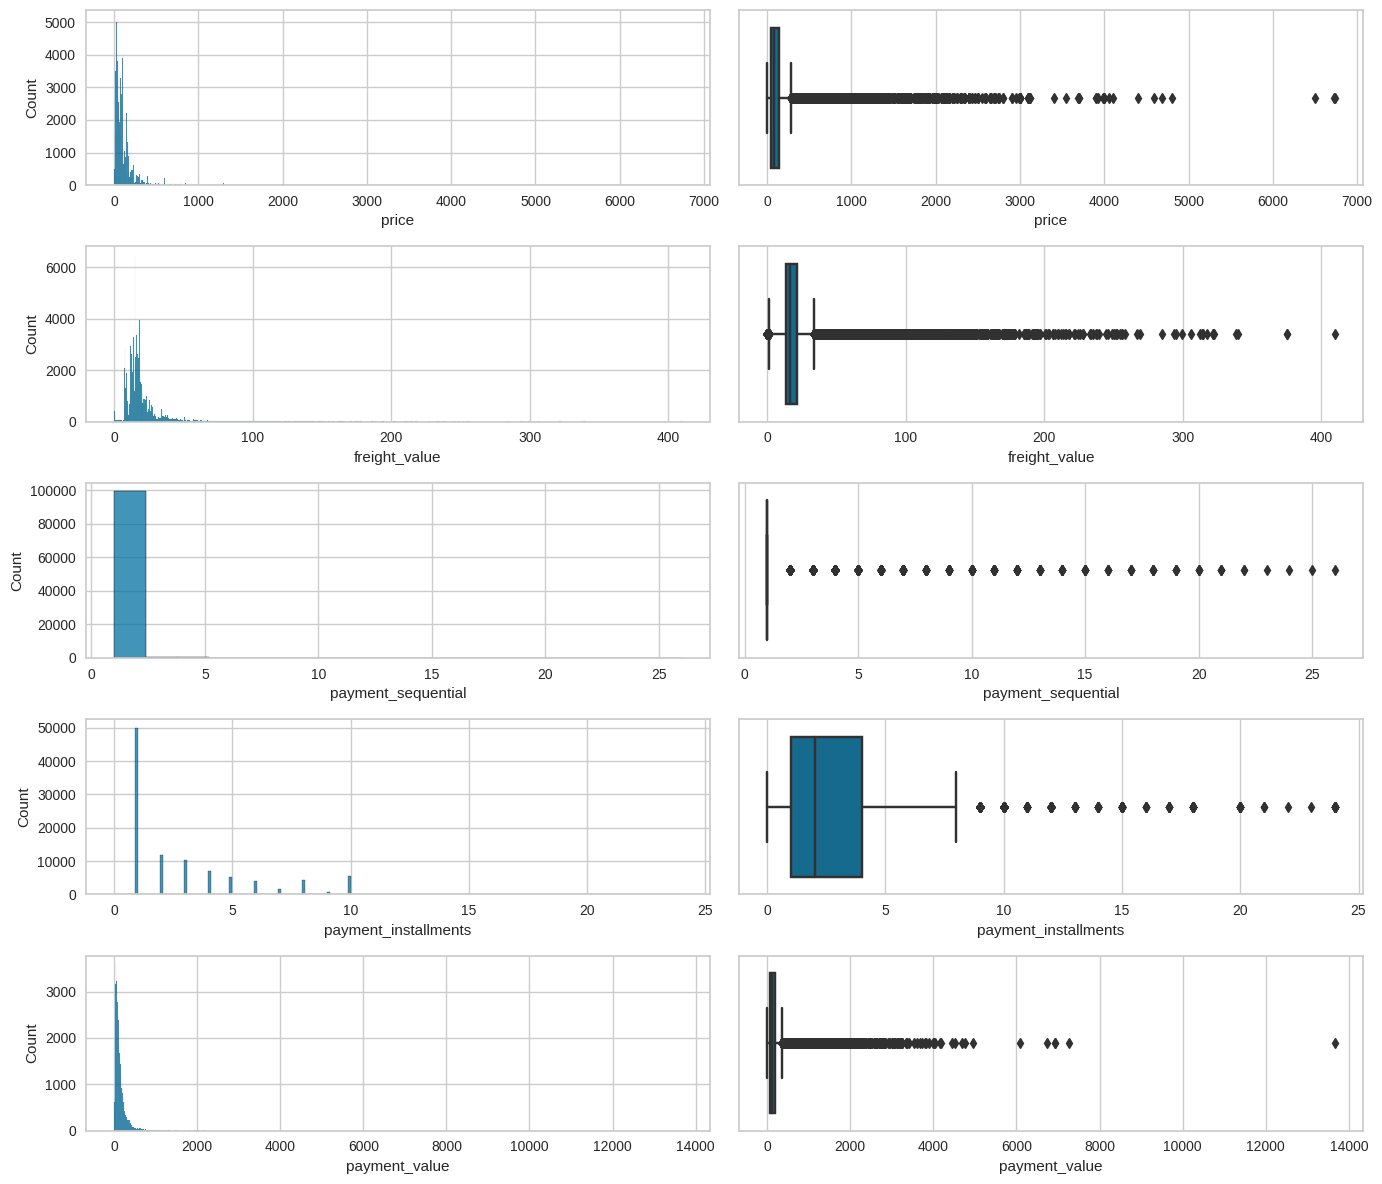

In [15]:
## Checking data distribution to decide which scaler wil be used

numerical_variables = customer_data.select_dtypes(include='number').columns

fig, ax = plt.subplots(len(numerical_variables),
                       2,
                       figsize=(14, 12))
ax = ax.ravel()
i = 0

for numerical_val in numerical_variables:
    sns.histplot(customer_data,
                 x=numerical_val,
                 ax=ax[i])

    sns.boxplot(customer_data,
                x=numerical_val,
                ax=ax[i+1])
    i += 2

plt.tight_layout()
plt.show()

As there are a lot of outliers in numerical variables, then we will use
the robust scaler to scale numerical data.

In [35]:
categorical_pipeline = Pipeline(
    steps=[
        ('encoder', OrdinalEncoder(dtype=np.int64))
    ]
)

In [36]:
numerical_pipeline = Pipeline(
    steps=[
        ('scaler', RobustScaler())
    ]
)

In [37]:
num_cols = customer_data.select_dtypes(include='number').columns.to_list()
cat_cols = customer_data.select_dtypes(include='object').columns.to_list()

preprocessing = ColumnTransformer(
    transformers=[
        ('num_transform', numerical_pipeline, num_cols),
        ('cat_transform', categorical_pipeline, cat_cols)
    ],
    remainder='passthrough'
)

In [38]:
customer_data_transformed = preprocessing.fit_transform(customer_data)
df_customer_data_transformed = pd.DataFrame(data=customer_data_transformed,
                                            columns=num_cols + cat_cols)
df_customer_data_transformed

,price,freight_value,payment_sequential,payment_installments,payment_value,customer_city,customer_state,product_category_name,payment_type
0,-0.500613,-0.960494,0.0,-0.333333,-0.714636,3563.0,25.0,73.0,1.0
1,-0.500613,-0.960494,1.0,-0.333333,-0.710691,3563.0,25.0,73.0,3.0
2,-0.500613,-0.960494,2.0,-0.333333,-0.849942,3563.0,25.0,73.0,3.0
3,0.405516,0.772840,0.0,-0.333333,0.320638,414.0,4.0,63.0,0.0
4,0.826353,0.335802,0.0,0.333333,0.636743,4016.0,8.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...
100825,-0.071502,-0.422222,0.0,0.333333,-0.152597,3520.0,25.0,11.0,1.0
100826,0.979571,0.444444,0.0,0.333333,0.770035,2974.0,25.0,9.0,1.0
100827,1.297140,5.990123,0.0,1.000000,1.408037,2521.0,4.0,30.0,1.0
100828,1.031563,2.974074,0.0,0.666667,2.836219,1917.0,18.0,45.0,1.0


To decide which clustering algorithm to be applied, we will plot the
data. Since it has a dimension greater than 2, then we will PCA and
T-distributed Stochastic Neighbor Embedding (TSNE) to reduce data
dimension to 3. Our objective is to check if there is any
clustering. Be aware that the codes below take some good time to
execute.

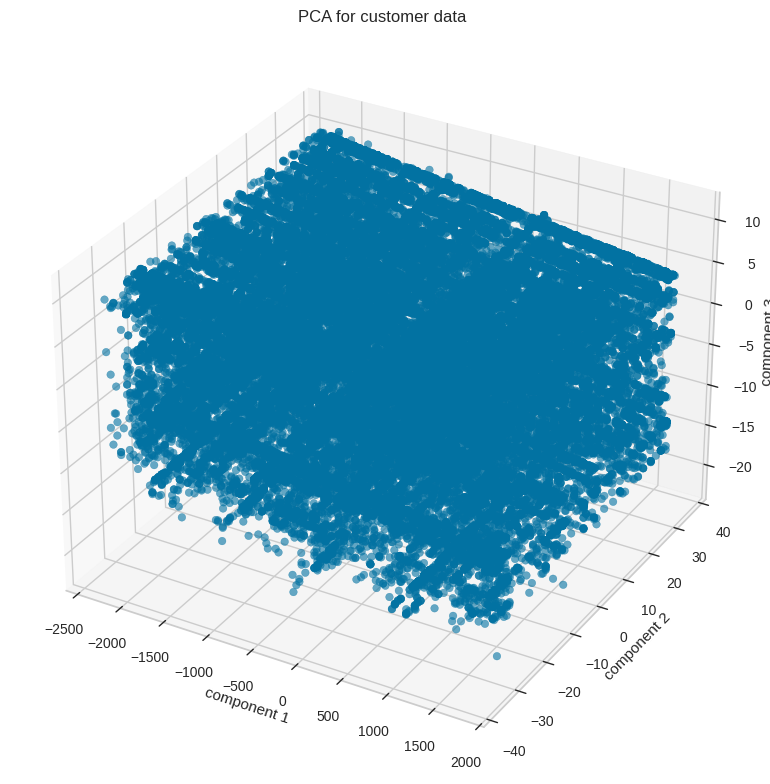

In [39]:
pca = PCA(n_components=3)
customer_data_PCA = pca.fit_transform(customer_data_transformed)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(customer_data_PCA[:, 0], 
           customer_data_PCA[:, 1],
           customer_data_PCA[:, 2],
           s=30,
           alpha=0.6)

ax.set_title('PCA for customer data')
ax.set_xlabel('component 1')
ax.set_ylabel('component 2')
ax.set_zlabel('component 3')

plt.tight_layout()
plt.show()

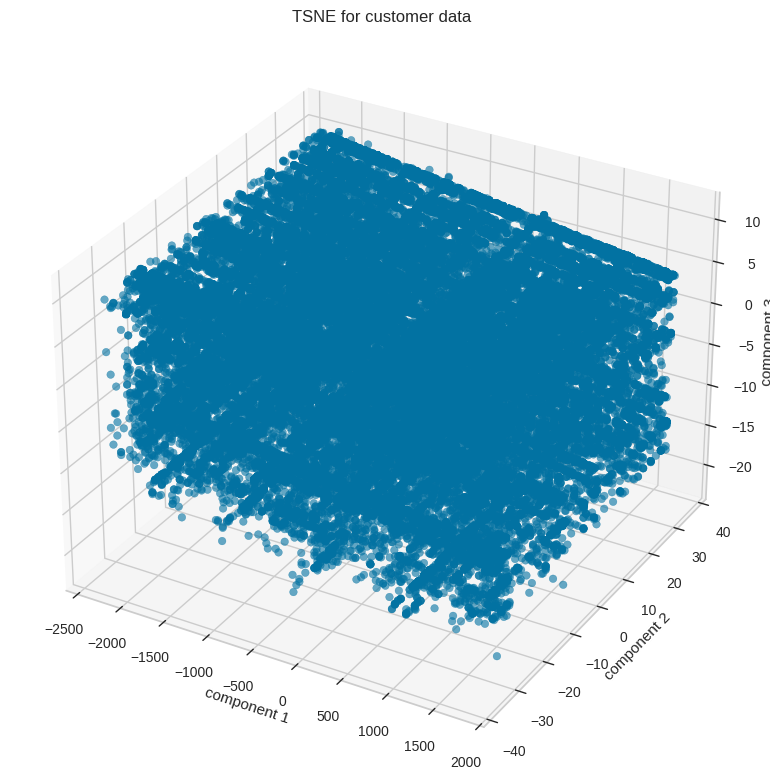

In [40]:
tsne = TSNE(n_components=3, perplexity=15, random_state=42)
customer_data_TSNE = tsne.fit_transform(customer_data_transformed)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(customer_data_PCA[:, 0], 
           customer_data_PCA[:, 1],
           customer_data_PCA[:, 2],
           s=30,
           alpha=0.6)

ax.set_title('TSNE for customer data')
ax.set_xlabel('component 1')
ax.set_ylabel('component 2')
ax.set_zlabel('component 3')

plt.tight_layout()
plt.show()

In [42]:
!pip install pacmap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 49.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 53.6 MB/s  0:00:01 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 54.4 MB/s  0:00:00 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pacmap]━━━━ 2/4 [numba]cpu]


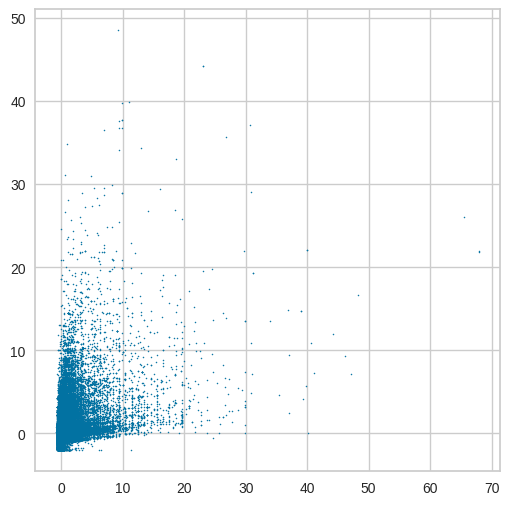

In [47]:
import pacmap
import matplotlib.pyplot as plt

embedding = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=10,
    MN_ratio=0.5,
    FP_ratio=2.0
)

customer_data_pacmap = embedding.fit_transform(
    customer_data_transformed,
    init="pca"
)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(
    customer_data_transformed[:, 0],
    customer_data_transformed[:, 1],
    s=0.6
)

Visually the points forms a single block and do not suggest existence of
clusters. For this reason, we are going to apply a hierarchical
clustering algorithm.

In [48]:
## ward linkage was chosen because it minimzes the cluster variance,
## thus clusters a more alike
agglo = AgglomerativeClustering(n_clusters=None,
                                distance_threshold=0,
                                linkage='ward')

## created a sample of 20% of data due to memory restrictions
n_samples = int(df_customer_data_transformed.shape[0] * 0.2)
sample = df_customer_data_transformed.sample(n=n_samples)
labels_agglo = agglo.fit(sample)

In [50]:
from sklearn.cluster import Birch

In [ ]:
## We tried to perform an incremental learning using Birch model
## but we could no did it, due to memory issues.

## training a clustering model
clustering_model = Birch(n_clusters=2)
## creates a chunk_size to perform an incremental learning
chunk_size = int(df_customer_data_transformed.shape[0] * 0.2)

for start in range(0, df_customer_data_transformed.shape[0], chunk_size):
    end = min(start + chunk_size, df_customer_data_transformed.shape[0])
    X = df_customer_data_transformed.iloc[start:end]
    clustering_model.partial_fit(X)

In [16]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

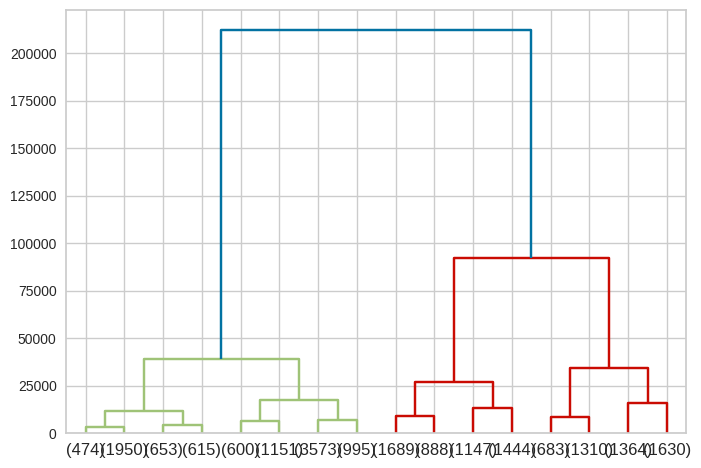

In [17]:
plot_dendrogram(agglo, truncate_mode="level", p=3)

Dendrogram suggest existance of two clusters. Now we train a model with
this amount of clusters.

In [18]:
cluster_model = AgglomerativeClustering(n_clusters=2,
                                        linkage='ward')
cluster_labels = cluster_model.fit_predict(sample)

In [19]:
customer_labels = customer_data.iloc[sample.index].copy()
customer_labels['cluster_label'] = cluster_labels
customer_labels

,customer_city,customer_state,price,freight_value,product_category_name,payment_sequential,payment_type,payment_installments,payment_value,cluster_label
7625,ouroeste,SP,219.90,17.17,cama_mesa_banho,1,boleto,1,237.07,0
66524,sao paulo,SP,29.50,8.72,eletronicos,1,boleto,1,38.22,1
78273,belo horizonte,MG,89.90,17.88,casa_conforto,1,credit_card,1,107.78,0
91279,sinop,MT,12.00,22.06,beleza_saude,2,voucher,1,22.79,1
21304,cachoeiro de itapemirim,ES,39.99,19.59,moveis_decoracao,1,credit_card,2,119.16,0
...,...,...,...,...,...,...,...,...,...,...
39707,brasilia,DF,119.90,18.09,beleza_saude,1,credit_card,5,137.99,0
36685,ribeirao das neves,MG,9.90,16.79,papelaria,1,credit_card,1,26.69,1
92262,taboao da serra,SP,229.90,14.05,esporte_lazer,1,credit_card,4,243.95,1
89985,maringa,PR,45.00,18.23,esporte_lazer,1,boleto,1,63.23,0


## 1.4 Analyzing cluster data
To analyze cluster data, we will perform univariate analysis for each
cluster found. First, we define the functions to perform this
task. Later we perform the analysis using the functions defined in
previous step.

In [40]:
def numerical_analysis(numerical_data: pd.DataFrame):
    """
    Print and plot information about numerical data.

    Arguments
    ---------
        numerical_data: a data frame containing only numerical data.
    """

    fig, ax = plt.subplots(numerical_data.shape[1],
                           2,
                           figsize=(12,10))
    ax = ax.ravel()
    i = 0

    for column in numerical_data.columns:
        sns.histplot(data=numerical_data,
                     x=column,
                     ax=ax[i])
        ax[i].set_title(f'Histogram - {column}')

        sns.boxplot(data=numerical_data,
                    x=column,
                    ax=ax[i+1])
        ax[i+1].set_title(f'Boxplot - {column}')
        i += 2

    plt.tight_layout()
    plt.show()
    print(f'Numerical data info.\n{numerical_data.describe().T}\n')

In [73]:
def categorical_analysis(categorical_data: pd.DataFrame):
    """
    Print and plot information about categorical data.

    Arguments
    ---------
        categorical_data: a data frame containing only categorical data.
    """

    for column in categorical_data.columns:
        column_data = categorical_data[column].value_counts().head()
        print(f'Information about {column}\n'
              f'{column_data}\n')

    fig, ax = plt.subplots(categorical_data.shape[1],
                           1,
                           figsize=(10, 10))

    for i, cat_col in enumerate(categorical_data.columns):
        column_data = categorical_data[cat_col].value_counts().head()
        column_data = column_data.reset_index()
        sns.barplot(data=column_data,
                    x=cat_col,
                    y='count',
                    ax=ax[i])

    plt.tight_layout()
    plt.show()

Analysing the data for cluster with label 0.

/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

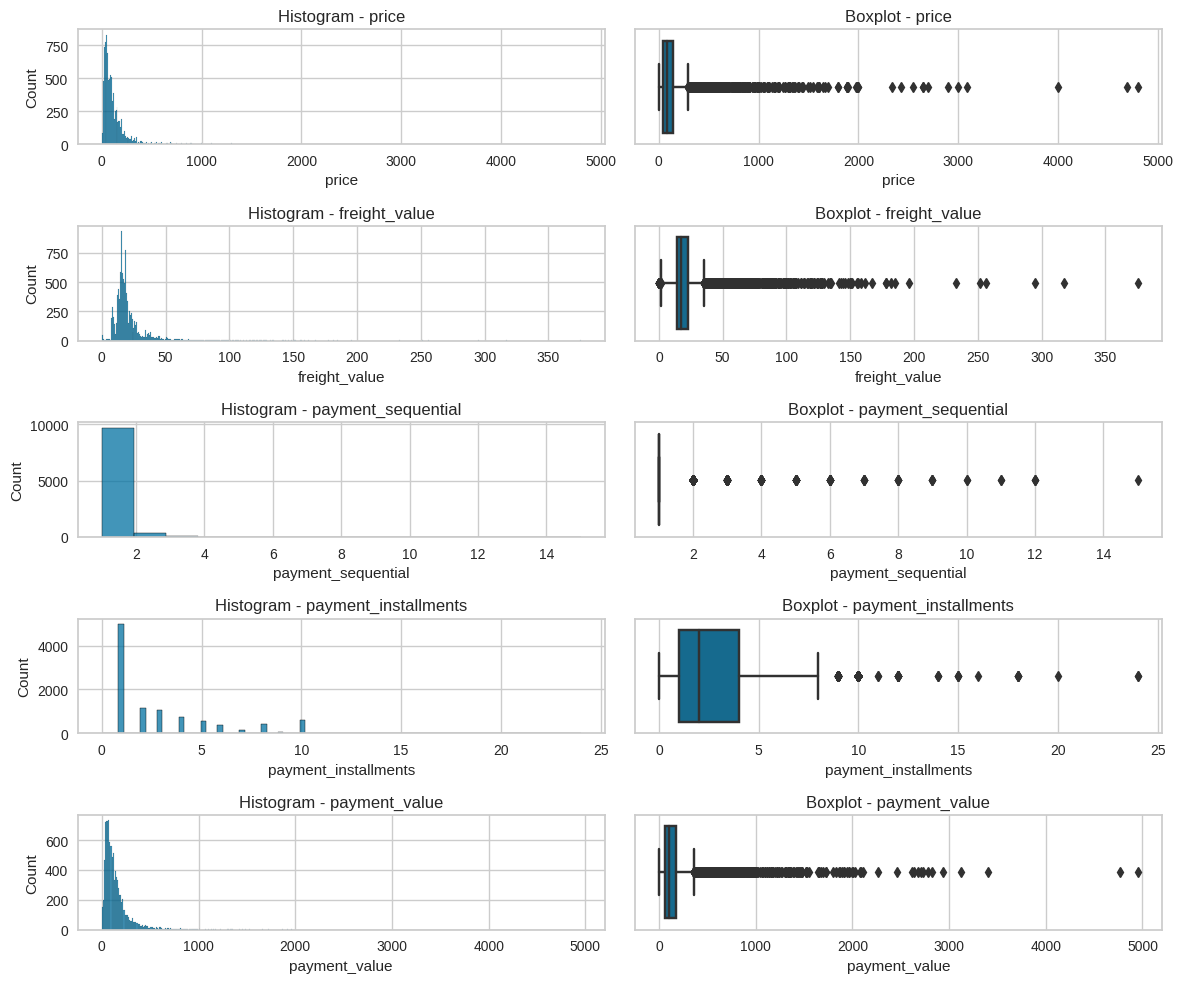

Numerical data info.
                        count        mean         std   min     25%     50%  \
price                 10155.0  127.297518  195.075315  0.85  43.990   79.90   
freight_value         10155.0   21.247328   16.604354  0.00  14.100   17.21   
payment_sequential    10155.0    1.082521    0.543449  1.00   1.000    1.00   
payment_installments  10155.0    2.962777    2.752797  0.00   1.000    2.00   
payment_value         10155.0  159.789070  213.531418  0.01  60.165  105.16   

                          75%      max  
price                 143.800  4799.00  
freight_value          22.505   375.28  
payment_sequential      1.000    15.00  
payment_installments    4.000    24.00  
payment_value         181.400  4950.34  



In [53]:
mask = customer_labels['cluster_label'] == 0
filtered_data = customer_labels[mask]
numerical_columns = filtered_data.select_dtypes(include='number').columns.to_list()
numerical_columns.remove('cluster_label')
numerical_analysis(filtered_data[numerical_columns])

Information about customer_city
customer_city
belo horizonte    542
brasilia          419
campinas          320
curitiba          308
guarulhos         249
Name: count, dtype: int64

Information about customer_state
customer_state
SP    3208
MG    1723
PR     812
RJ     778
SC     552
Name: count, dtype: int64

Information about product_category_name
product_category_name
cama_mesa_banho           1020
beleza_saude               863
esporte_lazer              756
moveis_decoracao           661
informatica_acessorios     660
Name: count, dtype: int64

Information about payment_type
payment_type
credit_card    7523
boleto         1945
voucher         548
debit_card      139
Name: count, dtype: int64



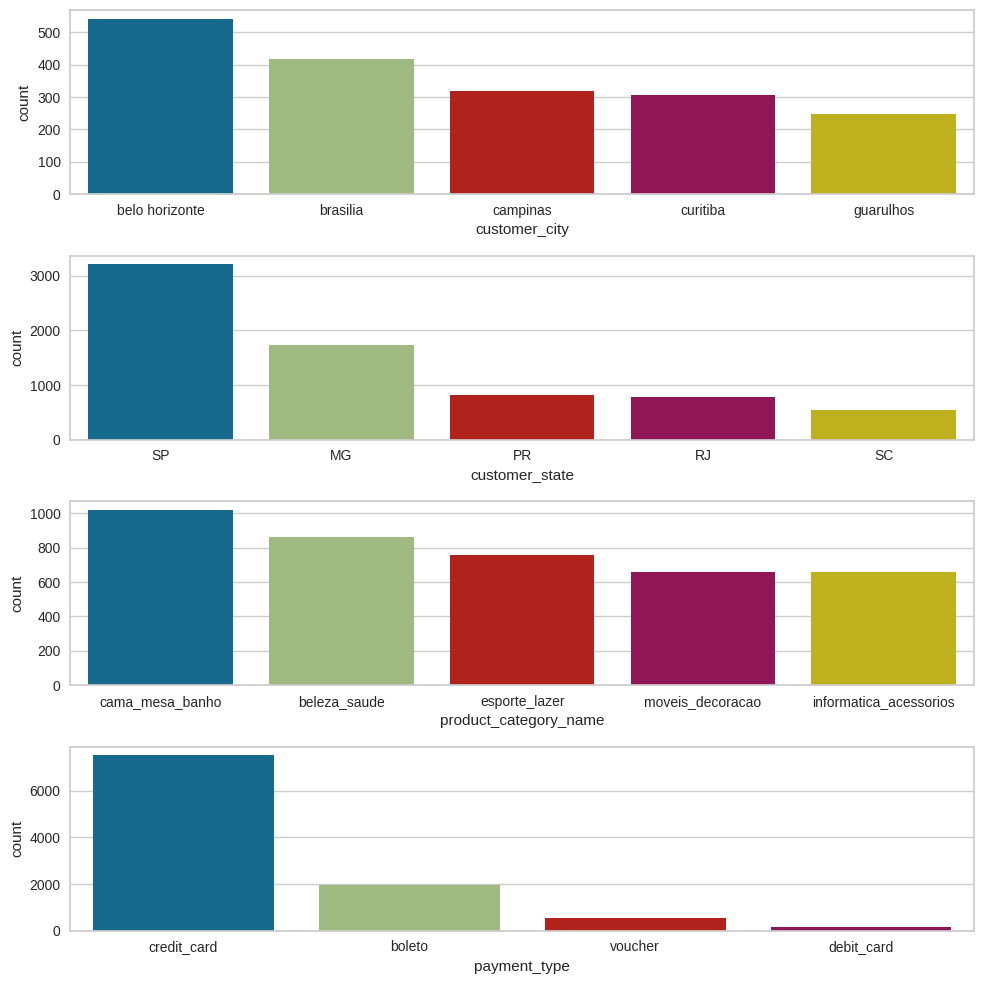

In [74]:
categorical_analysis(filtered_data.select_dtypes(include='object'))

Analysing the data for cluster with label 1.

/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/gasobral/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert in

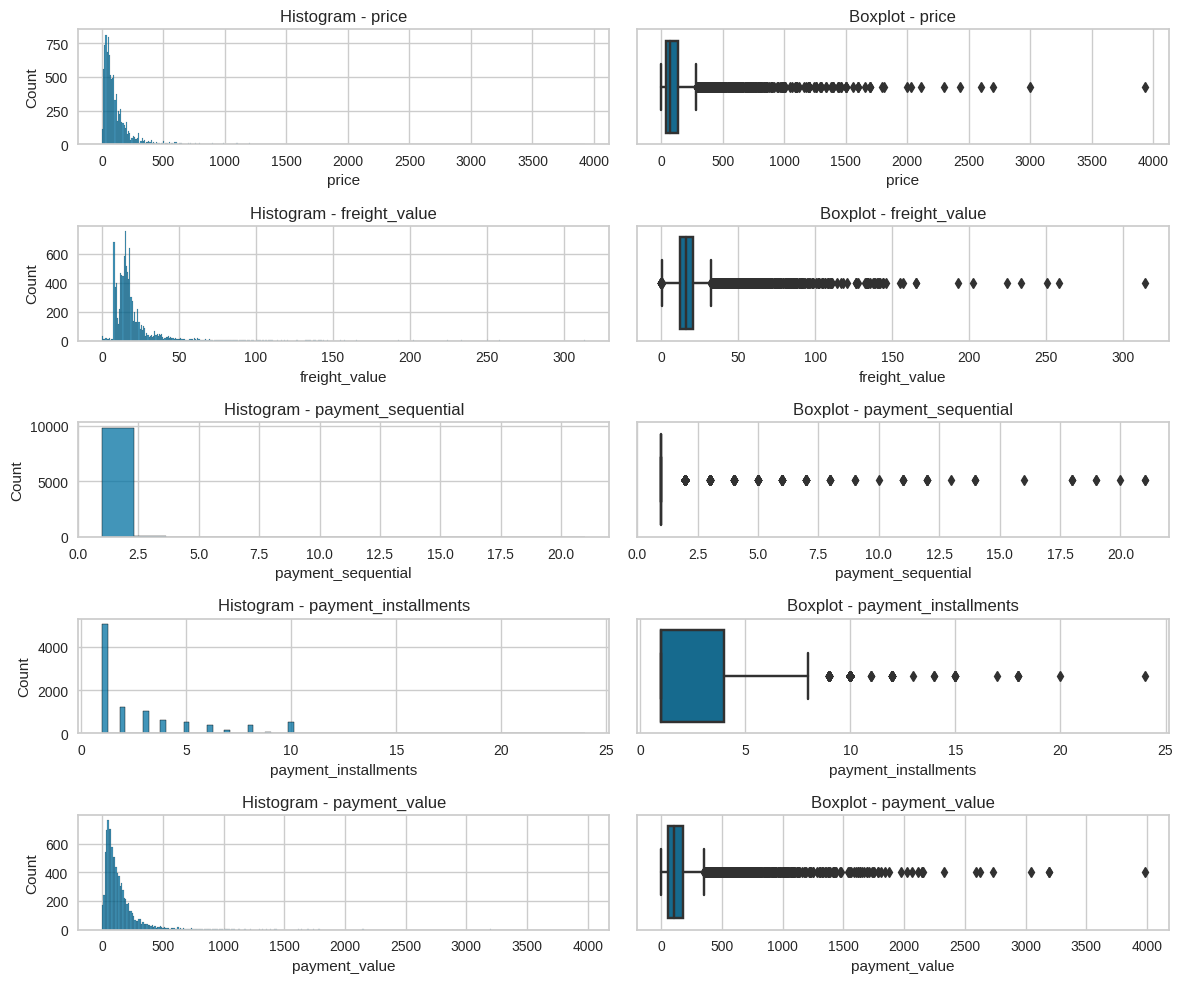

Numerical data info.
                        count        mean         std  min     25%     50%  \
price                 10011.0  120.870194  169.543915  1.2  39.990   76.00   
freight_value         10011.0   19.403124   15.357190  0.0  12.480   15.86   
payment_sequential    10011.0    1.110978    0.832393  1.0   1.000    1.00   
payment_installments  10011.0    2.867246    2.702804  1.0   1.000    1.00   
payment_value         10011.0  153.796139  198.902177  0.0  56.875  101.93   

                          75%      max  
price                 138.950  3930.00  
freight_value          20.430   314.02  
payment_sequential      1.000    21.00  
payment_installments    4.000    24.00  
payment_value         176.095  3979.55  



In [75]:
mask = customer_labels['cluster_label'] == 1
filtered_data = customer_labels[mask]
numerical_columns = filtered_data.select_dtypes(include='number').columns.to_list()
numerical_columns.remove('cluster_label')
numerical_analysis(filtered_data[numerical_columns])

Information about customer_city
customer_city
sao paulo         2885
rio de janeiro    1331
porto alegre       263
salvador           244
santo andre        170
Name: count, dtype: int64

Information about customer_state
customer_state
SP    5086
RJ    1768
MG     677
RS     637
BA     360
Name: count, dtype: int64

Information about product_category_name
product_category_name
cama_mesa_banho           1014
beleza_saude               850
esporte_lazer              769
moveis_decoracao           714
informatica_acessorios     664
Name: count, dtype: int64

Information about payment_type
payment_type
credit_card    7397
boleto         1867
voucher         588
debit_card      159
Name: count, dtype: int64



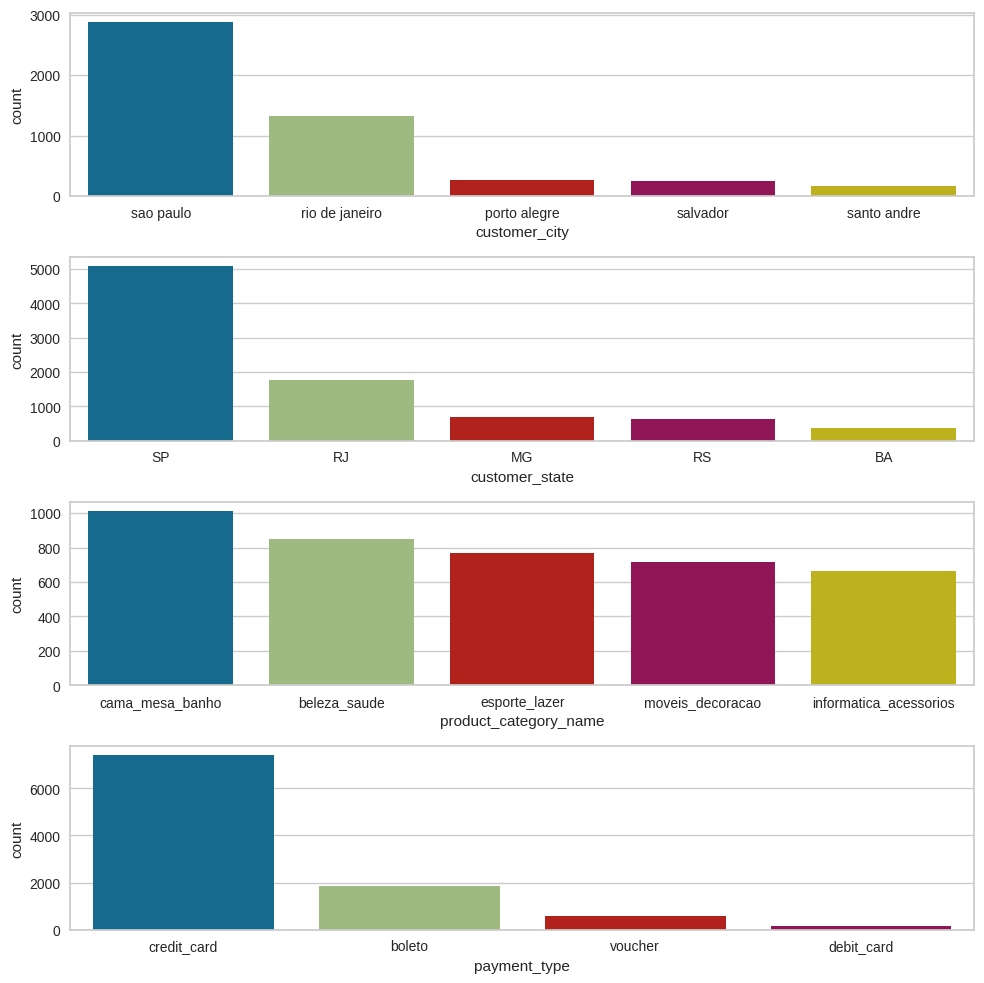

In [76]:
categorical_analysis(filtered_data.select_dtypes(include='object'))

In cluster with label 0, price and freight values show that most of the
buys have low values, which can indicate that most of customers use
e-commerce to buy items with small values. Payment sequential shows that
most of customers use only one method of payment. Moreover, most of buys
are payed within one installment. It is also important to note that are
records for payment installments raging from 2 to 6, since it is usually
offered tax free up to 6 installments. Credit card is the preferred way
of payment, followed by boleto and voucher. Since credit has no funding
issues (compared to debit card), allows installment payment and only
requires the payment to be within limit, then these reasons could
explain why it is a popular way of payment. However, it is recommend to
further analyze customer behavior to find its cause. And the categories
shows that the preferred segments (in decreasing order) are bed & bath &
table, health & beauty, sport, furniture & decor and informatics.

For cluster with label 1, price and freight values show a similar
behavior of cluster 0, however the values are smaller. The payment
sequential shows that the customers usually buy using two method of
payment, different from cluster 0 (which most of customer use only
one). The installment payment, product category and payment type show a
quite similar behavior to cluster 0. However, at cluster 1 most of
customers are located at the cities São Paulo, Rio de Janeiro and Porto
Alegre, whereas in cluster 0, they are at Belo Horizonte, Brasilia and
Campinas. In sum, the different between the two clusters (we could view
they as groups of customers) are at customer location and that customers
of cluster 1 usually use two methods of payments, despite of cluster 0
where most customers use one method. But the clusters are alike in
customer preferred way of payment and product categories.

# Conclusion

We could successfully identify and gather the data regarding customer
location and buys for customer segmentation. Moreover, after some
analysis, we found that a hierarchical clustering algorithm should be
used instead of $k$-Means. By following this approach, we found the
customers could be split (not necessarily even) into two clusters. They
are alike in payment type, product category, price, freight value and
payment installments. Most of customers use credit card, buy items with
small value and the preferred categories are: bed & bath & table, health
& beauty, sport, furniture & decor and informatics. About payment
installment, customers usually use one. But some installment payment
range from 2 to 6 because some e-commerce offers tax free up to 6
installments. However, they differ at customer location and payment
sequential. One group of customer uses only one payment method, while
the other group uses two. These information can be useful to describe
customer behavior and to suggest campaigns for most popular categories.